In [2]:
import matplotlib.pyplot as plt
import matplotlib
from functools import partial
import numpy as np
import pickle
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

col = (3.5,3.5)
col_margins = {'top':0.98,'right':0.98,'left':.2,'bottom':.15}
wide = (7.5,3.5)
wide_margins = {'top':0.98,'right':0.98,'left':.1,'bottom':.15}
full = (7.5,6)
full_margins = {'top':0.98,'right':0.98,'left':.1,'bottom':.1}

matplotlib.rcParams.update({'font.size': 11})
matplotlib.rcParams.update({'axes.grid':True})
matplotlib.rcParams.update({'xtick.direction':'in'})
matplotlib.rcParams.update({'ytick.direction':'in'})
matplotlib.rcParams.update({'xtick.top':True})
matplotlib.rcParams.update({'ytick.right':True})
matplotlib.rcParams.update({'legend.fontsize':'small'})
matplotlib.rcParams.update({'legend.frameon':False})
matplotlib.rcParams.update({'legend.fancybox':False})
matplotlib.rcParams.update({'legend.framealpha':0.6})
matplotlib.rcParams.update({'lines.dashed_pattern':[7,3]})
matplotlib.rcParams.update({'lines.dashed_pattern':[7,3]})

In [3]:
perfs = pickle.load( open('/home/mvancuyck/Desktop/TODs_profiling/namap_perf_profiling.p', 'rb'))
perfs.keys()

dict_keys(['profiling vs tod time', 'profiling vs resolution', 'profiling vs nb of detectors', 'profiling vs nb bands', 'profiling fcts'])

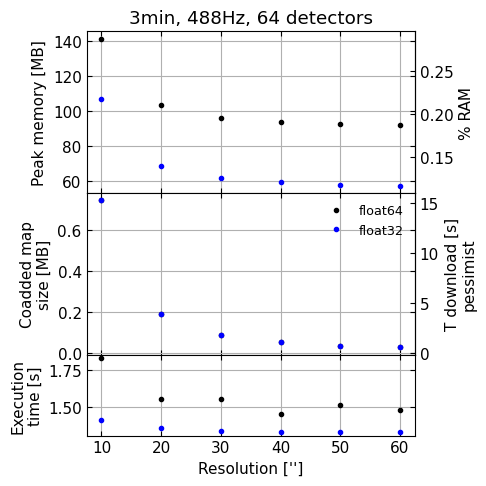

In [9]:
fig, (axm, axb, axt) = plt.subplots(3,figsize=(5,5), sharex=True,gridspec_kw={'height_ratios': [2, 2, 1]})
key = 'profiling vs resolution'
key2 = "resolution ['']"

for precision, color in zip(('float64', 'float32'),('k','b','r')): 
    axm.plot(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], f'.{color}')
    axb.plot(perfs[key][key2], perfs[key][precision]['output size [MB]'], f'.{color}', label= precision)
    axt.plot(perfs[key][key2], perfs[key][precision]['time [s]'], f'.{color}')


def f_to_z(x): return x/49152*100
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')


def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')


ymin, ymax = axm.get_ylim()
axb.legend()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
axm.set_title('3min, 488Hz, 64 detectors')
axt.set_xlabel("Resolution ['']")
axb.set_ylabel('Coadded map\nsize [MB]')

fig.tight_layout()
fig.subplots_adjust(hspace=0)

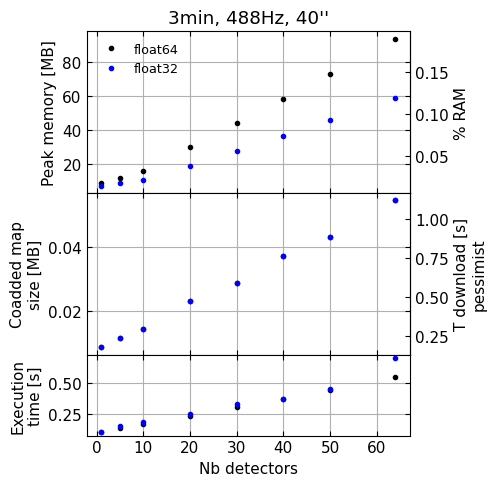

In [5]:
fig, (axm, axb, axt) = plt.subplots(3,figsize=(5,5), sharex=True,gridspec_kw={'height_ratios': [2, 2, 1]})
key = 'profiling vs nb of detectors'
key2 = "nb detectors"

for precision, color in zip(('float64', 'float32'),('k','b','r')): 
    axm.plot(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], f'.{color}', label= precision)
    axb.plot(perfs[key][key2], perfs[key][precision]['output size [MB]'], f'.{color}')
    axt.plot(perfs[key][key2], perfs[key][precision]['time [s]'], f'.{color}')

def f_to_z(x): return x/49152*100
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')


def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')

ymin, ymax = axm.get_ylim()
axm.legend()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
axm.set_title("3min, 488Hz, 40''")
axt.set_xlabel("Nb detectors")
axb.set_ylabel('Coadded map\nsize [MB]')

fig.tight_layout()
fig.subplots_adjust(hspace=0)

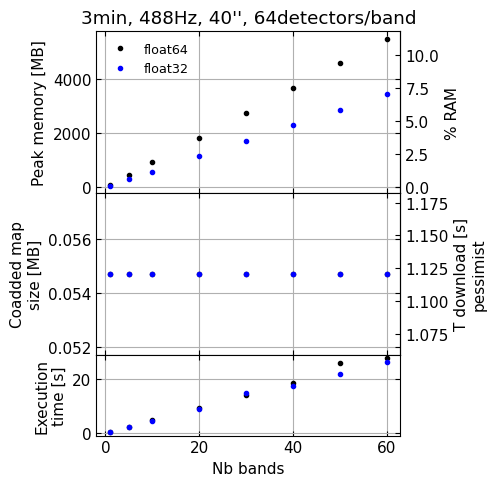

In [6]:
fig, (axm, axb, axt) = plt.subplots(3,figsize=(5,5), sharex=True,gridspec_kw={'height_ratios': [2, 2, 1]})
key = 'profiling vs nb bands'
key2 = "nb bands"

def f_to_z(x): return x/49152*100
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')


for precision, color in zip(('float64', 'float32'),('k','b','r')): 
    axm.plot(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], f'.{color}', label= precision)
    axb.plot(perfs[key][key2], perfs[key][precision]['output size [MB]'], f'.{color}')
    axt.plot(perfs[key][key2], perfs[key][precision]['time [s]'], f'.{color}')

ymin, ymax = axm.get_ylim()
axm.legend()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
axm.set_title("3min, 488Hz, 40'', 64detectors/band")
axt.set_xlabel("Nb bands")
axb.set_ylabel('Coadded map\nsize [MB]')

fig.tight_layout()
fig.subplots_adjust(hspace=0)

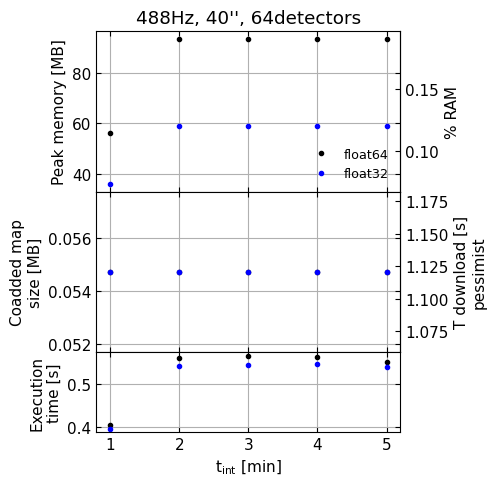

In [7]:
fig, (axm, axb, axt) = plt.subplots(3,figsize=(5,5), sharex=True,gridspec_kw={'height_ratios': [2, 2, 1]})
key = 'profiling vs tod time'
key2 = "t_int"

for precision, color in zip(('float64', 'float32'),('k','b','r')): 
    axm.plot(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], f'.{color}', label= precision)
    axb.plot(perfs[key][key2], perfs[key][precision]['output size [MB]'], f'.{color}')
    axt.plot(perfs[key][key2], perfs[key][precision]['time [s]'], f'.{color}')


def f_to_z(x): return x/49152*100
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')


ymin, ymax = axm.get_ylim()
axm.legend()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
axm.set_title("488Hz, 40'', 64detectors")
axt.set_xlabel("$\\rm t_{int}$ [min]")
axb.set_ylabel('Coadded map\nsize [MB]')

fig.tight_layout()
fig.subplots_adjust(hspace=0)

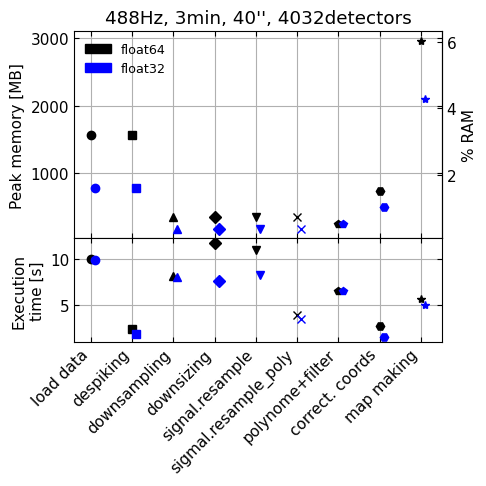

In [8]:
fig, (axm, axt) = plt.subplots(2,figsize=(5,5), sharex=True,gridspec_kw={'height_ratios': [2,  1]})
key = 'profiling fcts'
fcts_list = ('loaddata','despiking','zoom_sync', 'zoom_sync_v2', 'zoom_sync_v3','zoom_sync_v4','polynome_fft_filter','correct_coords','map_making')
fcts_list_name = ('load data','despiking','downsampling', 'downsizing', 'signal.resample','sigmal.resample_poly','polynome+filter','correct. coords','map making')

patchs = []
for ip, (precision, color) in enumerate(zip(('float64', 'float32'),('k','b','r'))): 
    patch = mpatches.Patch(color=color, label= precision); patchs.append(patch); 

    for fi, (fct, m) in enumerate(zip(fcts_list,('o', 's', '^', 'D', 'v', 'x', 'p', 'H','*'))):

        #if(color=='b'): patch = mlines.Line2D([], [], color='k', linestyle='None',marker=m,  label=fct); patchs.append(patch)
        axm.plot((fi+1+0.1*ip), perfs[key][precision][fct]['peak memory [MB]'], color=f'{color}', marker = m)
        axt.plot((fi+1+0.1*ip), perfs[key][precision][fct]['time [s]'], color=f'{color}', marker = m)

def f_to_z(x): return x/49152*100
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

ymin, ymax = axm.get_ylim()
axm.legend(handles=patchs)
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
axm.set_title("488Hz, 3min, 40'', 4032detectors")

axt.set_xticks(range(1, len(fcts_list)+1))
axt.set_xticklabels(fcts_list_name, rotation=45, ha='right')


fig.tight_layout()
fig.subplots_adjust(hspace=0)

In [16]:
dict2['size'][:,2,1,1]

array([0.308598, 0.328294, 0.351288, 0.351288, 0.40824 , 0.46539 ,
       0.384704, 0.483542, 0.580933, 0.483542, 0.671512, 0.875318,
       0.671512, 1.060366, 1.428468, 0.762944, 1.268382, 1.728287,
       0.875318, 1.428468, 2.034422, 1.49181 , 2.690621, 3.882933])

In [17]:
dict2 =  pickle.load( open('/home/mvancuyck/Desktop/TODs_profiling/tod_profiling_vs_nb_dets.p', 'rb'))
dict1 =  pickle.load( open('/home/mvancuyck/Desktop/TODs_profiling/tod_profiling.p', 'rb'))

d={}
for j, f in enumerate(dict2['data_freq']):
    for k, b in enumerate(dict2['format']): 
        d[f'{f:.0f}Hz_{b}bit'] = {}
        d[f'{f:.0f}Hz_{b}bit']['num_detectors'] = dict2['nb dets']
        d[f'{f:.0f}Hz_{b}bit']['weights_mb']    = dict2['size'][:,2,j,k]
for j, f in enumerate(dict2['data_freq']):
    d[f'_{f:.0f}Hz_16bit'] = {}
    d[f'_{f:.0f}Hz_16bit']['num_detectors'] = dict2['nb dets']
    for i, t in enumerate(dict2['time [min]']): 
        d[f'_{f:.0f}Hz_16bit'][f'{t}min weights_mb'] = dict2['size'][:,i,j,1]
        
times = dict2['time [min]']

KeyError: '488Hz_64bit'

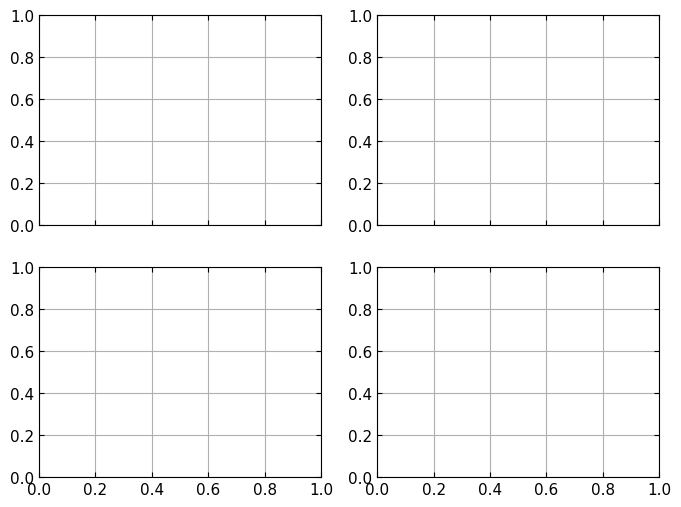

In [18]:
fig, axs = plt.subplots(2,2,figsize=(8,6), sharex=True)

for it, (t, l) in enumerate(zip((20,0.0488*60), ('s', 'min'))):
    for fi, f in enumerate(('488','100')):
        for b,c in zip(('64','32','16'), ('k', 'b','r')):
            axs[it,fi].plot(d[f'{f}Hz_{b}bit']['num_detectors'], d[f'{f}Hz_{b}bit']['weights_mb'], f'.{c}', label=f'{b}B')
        axs[0,0].legend()
        axs[1,fi].set_xlabel('nb detectors')
        axs[it,fi].set_ylabel('TOD.hdf5 size [MB]')
        axs[0,fi].set_title(f'{f}Hz')
        
        def f_to_z(x,telemetry,): return x/telemetry
        f_single = partial(f_to_z, telemetry=t)  # example value
        secax = axs[it,fi].secondary_yaxis("right", functions=(f_single,f_single))
        secax.set_ylabel(f'T download [{l}]')

fig.suptitle('2 minutes')
fig.tight_layout()
fig.subplots_adjust(hspace=0)


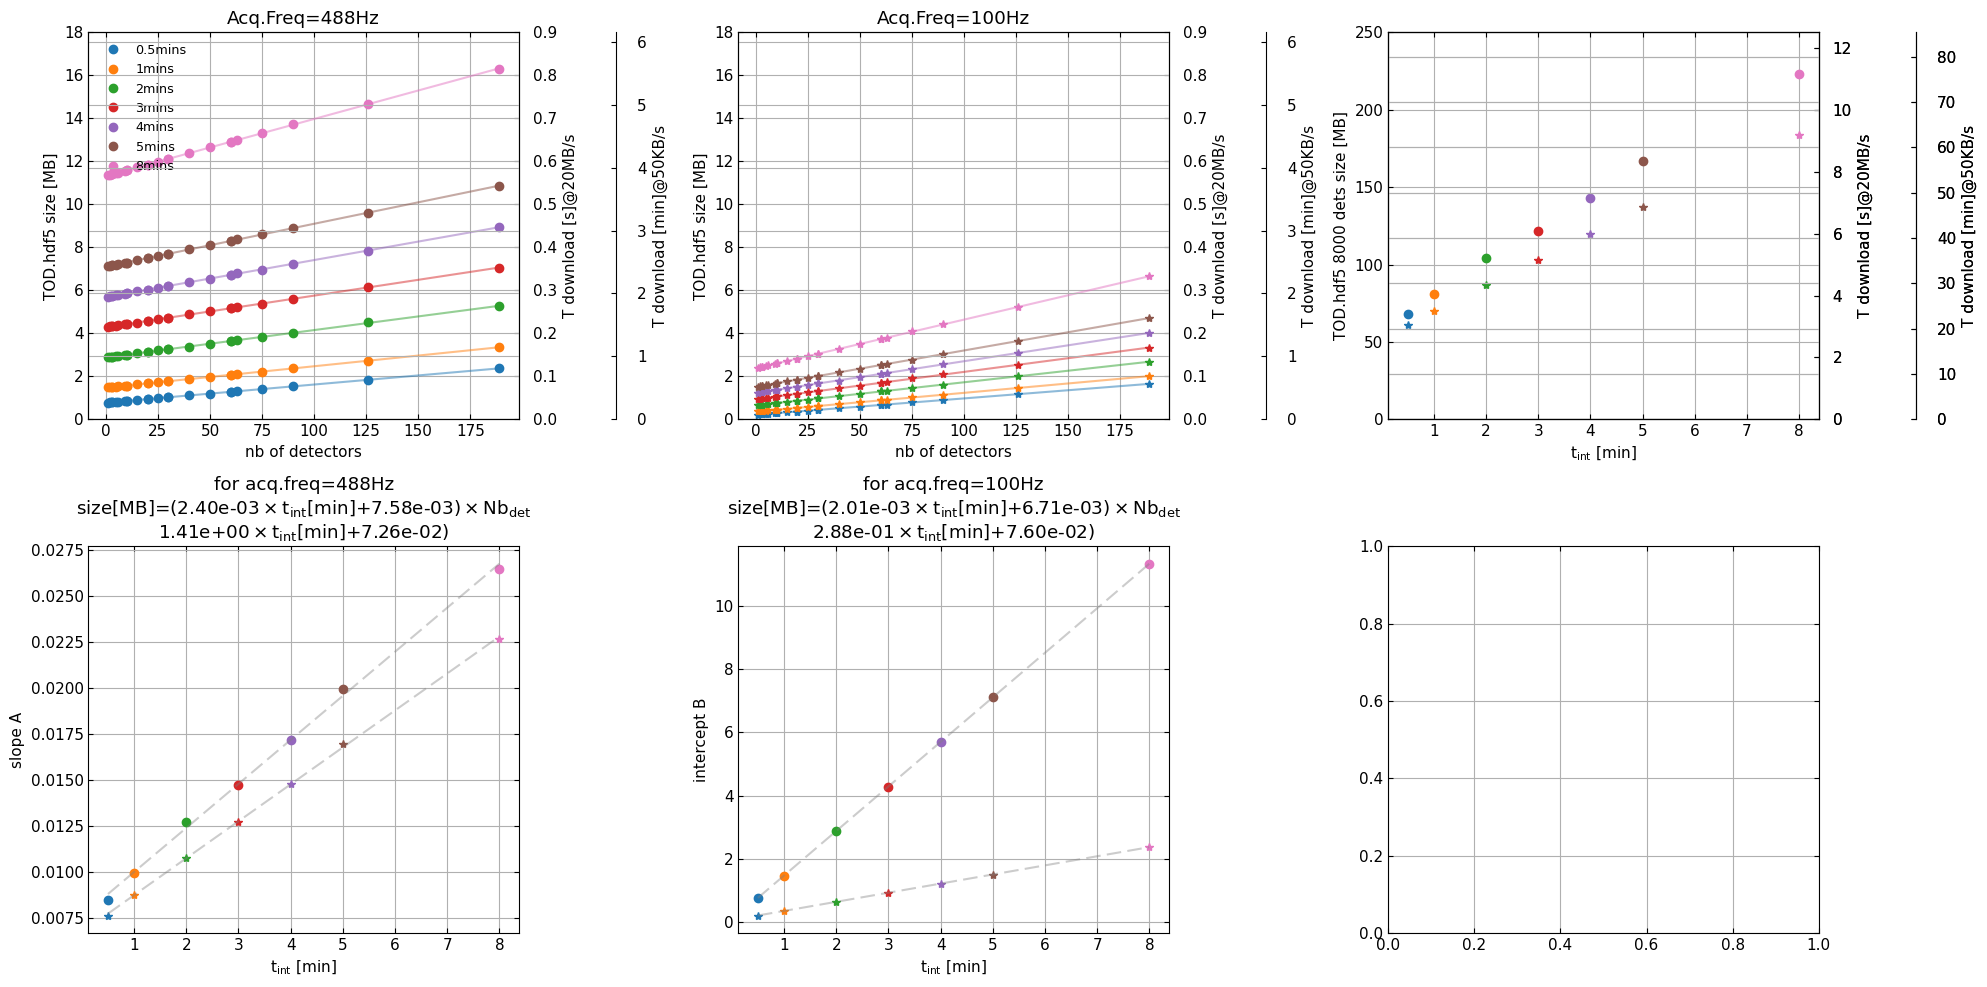

In [52]:
# Create 1x3 subplots
fig, axs = plt.subplots(2, 3, figsize=(20, 10), )

for fi, (f, m) in enumerate(zip(('488','100',), ('o', '*', ''))):
    a_list = []
    b_list = []

    for t, c in zip(times, ('tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink')):
        if(fi>1): continue
        x = d[f'_{f}Hz_16bit']['num_detectors']
        axs[0,fi].plot(x, d[f'_{f}Hz_16bit'][f'{t}min weights_mb'],m, c=c, label=f'{t}mins')

        coeffs = np.polyfit(x, d[f'_{f}Hz_16bit'][f'{t}min weights_mb'], 1)  # [slope, intercept]
        a, b = coeffs
        y_7000 = np.polyval(coeffs, 8000)
        x_fit = np.linspace(min(x), max(x), 200)
        y_fit = np.polyval(coeffs, x_fit)
        axs[0,fi].plot(x_fit, y_fit, color=c, alpha=0.5)
        axs[0,fi].set_title(f'Acq.Freq={f}Hz')
        axs[0,fi].set_xlabel('nb of detectors')
        axs[0,2].plot(t, y_7000,m,c=c, )
        axs[0,2].set_xlabel('$\\rm t_{int}$ [min]')
        axs[0,2].set_ylabel('TOD.hdf5 8000 dets size [MB]')
        axs[0,0].set_ylabel('TOD.hdf5 size [MB]')
        axs[0,1].set_ylabel('TOD.hdf5 size [MB]')

        axs[1,0].plot(t, a,m,c=c, )
        axs[1,0].set_xlabel('$\\rm t_{int}$ [min]')
        axs[1,0].set_ylabel('slope A')
        a_list.append(a)

        axs[1,1].plot(t, b,m,c=c, )
        axs[1,1].set_xlabel('$\\rm t_{int}$ [min]')
        axs[1,1].set_ylabel('intercept B')
        b_list.append(b)

    axs[0,fi].set_ylim(0,18)
    axs[0,2].set_ylim(0,250)



    a_coeffs = np.polyfit(times, np.asarray(a_list), 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(times), max(times), 200)
    y_lin = p_lin(x_fit)
    axs[1,0].plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)


    b_coeffs = np.polyfit(times, np.asarray(b_list), 1)
    p_lin = np.poly1d(b_coeffs)
    x_fit = np.linspace(min(times), max(times), 200)
    y_lin = p_lin(x_fit)
    axs[1,1].plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    axs[1,fi].set_title(f'for acq.freq={f}Hz\nsize[MB]=({a_coeffs[0]:.2e}'+'$\\rm \\times t_{int}[min]$'+f'+{a_coeffs[1]:.2e})'+'$\\rm \\times Nb_{det}$\n'
                            +f'{b_coeffs[0]:.2e}'+'$\\rm \\times t_{int}[min]$'+f'+{b_coeffs[1]:.2e})')

    
    # ---------------------------
    # First right y-axis (secondary_yaxis)
    # ---------------------------

    def f_to_z(x,telemetry,): return x/telemetry
    f_single = partial(f_to_z, telemetry=1)  # example value
    secax1 = axs[0,fi].secondary_yaxis("right", functions=(f_single,f_single))
    secax1.set_ylabel(f'T download [s]@1MB/s')
    secax1.tick_params(axis='y', pad=10, direction='in')

    # ---------------------------
    # Second right y-axis (twinx, shifted outward)
    # ---------------------------
    ax2 = axs[0,fi].twinx()
    telemetry_ax2 = 0.0488*60
    ax2.set_ylim(axs[0,fi].get_ylim()[0]/telemetry_ax2, axs[0,fi].get_ylim()[1]/telemetry_ax2)    # Shift outward by 60 points to the right, independent of subplot
    ax2.spines['right'].set_position(('outward', 70))
    ax2.set_ylabel(f'T download [min]@50KB/s')
    ax2.tick_params(axis='y', pad=15)

    #--

    def f_to_z(x,telemetry,): return x/telemetry
    f_single = partial(f_to_z, telemetry=20)  # example value
    secax1 = axs[0,2].secondary_yaxis("right", functions=(f_single,f_single))
    secax1.set_ylabel(f'T download [s]@20MB/s')
    secax1.tick_params(axis='y', pad=10, direction='in')

    # ---------------------------
    # Second right y-axis (twinx, shifted outward)
    # ---------------------------
    ax2 = axs[0,2].twinx()
    telemetry_ax2 = 0.0488*60
    ax2.set_ylim(axs[0,2].get_ylim()[0]/telemetry_ax2, axs[0,2].get_ylim()[1]/telemetry_ax2)    # Shift outward by 60 points to the right, independent of subplot
    ax2.spines['right'].set_position(('outward', 70))
    ax2.set_ylabel(f'T download [min]@50KB/s')
    ax2.tick_params(axis='y', pad=15)
    
    
# Add legend to the first subplot
axs[0,0].legend(loc='upper left')

plt.tight_layout()
plt.show()
